# Stereo Visual Odometry Example (Large Dataset)

In this notebook we build on `StereoVOExample.ipynb` to tackle a more realistic stereo visual-odometry problem. A robot carries a stereo camera, moves forward over a longer trajectory, and observes a large sample of landmarks. Our goals are:

1. Define a noise model and stereo calibration.  
2. Assemble a factor graph of stereo-measurement factors.  
3. Provide initial estimates for both camera poses and landmark positions.  
4. Run Levenberg–Marquardt optimization to recover the most likely trajectory and map.  
5. Analyze and visualize final poses and landmarks.


If any section may seem unclear, we recommend looking at `StereoVOExample.ipynb` first and coming back to this example afterwards. 

**Note:** This example is also available in C++. If you're interested in the C++ implementation, refer to `StereoVOExample_large.cpp` in the [GTSAM examples directory](https://github.com/borglab/gtsam/tree/develop/examples).

GTSAM Copyright 2010-2025, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/StereoVOExample_large.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
try:
    import google.colab
    print("Running in Google Colab, installing necessary libraries...")
    %pip install --quiet gtsam-develop
    print("Done!")
except ImportError:
    print("Not running in Google Colab. Please install necessary libraries as needed.")
    pass # Not in Colab

Not running in Google Colab. Please install necessary libraries as needed.


In [1]:
import gtsam
import gtsam.utils.plot as gtsam_plot
import numpy as np

# For shorthand for common GTSAM types (like X for poses, L for landmarks)
from gtsam.symbol_shorthand import X, L

## 1. Setup Factor Graph

We start by creating an empty `NonlinearFactorGraph`.

In [2]:
# Create an empty nonlinear factor graph
graph = gtsam.NonlinearFactorGraph()

## 2. Define Camera Calibration and Measurement Noise
- **Noise Model:** We define an isotropic noise model for the stereo measurements. `Isotropic.Sigma(3, 1.0)` means a 3-dimensional noise (for $u_L, u_R, v$) with a standard deviation of 1 pixel for each dimension.
- **Camera Calibration ([`Cal3_S2Stereo`](/gtsam/geometry/doc/Cal3_S2Stereo.ipynb)):** We download the calibration parameters text file from the GTSAM Github and setup a stereo calibration model with those parameters:
  - $f_x=f_y=721.5377$
  - $s=0$
  - $(u,v)=(609.5593,\,172.854)$
  - $b=0.537150588$

In [3]:
# Retrieve Calibration file
cal_params_file = gtsam.findExampleDataFile("VO_calibration.txt")

# Read calibration parameters
cal_params = np.loadtxt(cal_params_file)

# Create a Cal3_S2Stereo calibration object
K = gtsam.Cal3_S2Stereo(cal_params)
print(K)

# Define the stereo measurement noise model (isotropic, 1 pixel standard deviation)
measurement_noise_model = gtsam.noiseModel.Isotropic.Sigma(3, 1.0)

K: 721.538       0 609.559
      0 721.538 172.854
      0       0       1
Baseline: 0.537151



## 3. Construct Initial Pose Estimates from Odometry Measurements

The next step in our visual odometry pipeline is to provide an initial guess for the robot's trajectory. GTSAM relies on good initial values for its nonlinear optimization process to converge accurately and efficiently. These initial pose estimates serve as a prior that guides the optimizer toward a globally consistent solution.

In this example, the pose data is stored in a text file, where each row corresponds to a unique camera pose. Each row contains 17 values:
- The first value is an integer index/ID that identifies the camera pose.
- The remaining 16 values encode the camera's 3D pose as a flattened $4\times 4$ transformation matrix, stored in row-major order. This matrix represents a rigid body transformation in $SE(3)$, combining both rotation and translation.

The file contains pose data for 26 time steps along the robot's trajectory. We load these poses and insert them into a `gtsam.Values` object named `initial_estimates`. This object functions like a dictionary, mapping symbolic keys (e.g. `X(1)`, `X(2)`,...) to corresponding `Pose3` objects. These estimates will later be refined during optimization, but they must be reasonably close to the true trajectory to ensure successful convergence.

In [4]:
# Odometry data file with camera poses
odometry_data_file = gtsam.findExampleDataFile("VO_camera_poses_large.txt")

# Read poses
camera_poses = np.loadtxt(odometry_data_file)

# Create a gtsam.Values object to hold the pose data
initial_estimates = gtsam.Values()

# Parse the raw camera pose data
for pose in camera_poses:
	pose_id = int(pose[0])
	m = pose[1:].copy().reshape(4, 4)
	initial_estimates.insert(X(pose_id), gtsam.Pose3(m))

## 4. Load Stereo Pixel and Landmark Coordinates

The factor data file stores the pixel coordinates $(u_L, u_R, v)$ and landmark coordinates $(X, Y, Z)$ in the camera frame. Note that there is only one set of pixel coordinates per entry due image rectification, and the landmark coordinates are results from triangulation. Just like the pose data, each row, with 8 values, represents a distinct entry; the first two values are the pose ID and the landmark ID, respectively, the next triplet of values represent the pixel coordinates $(u_L, u_R, v)$, and the last triplet of values represent the landmark coordinates $(X, Y, Z)$.

## 4. Load and Inspect Stereo Measurement Data
In this section, we load the raw stereo measurement data that encodes the pixel observations and 3D landmark positions captured by the robot's stereo camera. This data provides the core geometric constraints that link camera poses to landmarks in our factor graph.

Each row in the data file represents a single stereo observation, consisting of eight values:
- The first two values are integer indices/IDs: one for the camera pose and one for the landmark.
- The next three values are the rectified stereo pixel coordinates $(u_L, u_R, v)$. These represent horizontal pixel positions in the left and right images and the sharted vertical coordinate.
- The last three values are the 3D coordinates $(X, Y, Z)$ of the observed landmark, expressed in the camera frame using stereo triangulation.

This data will be used in the next steps to build measurement factors and initialize landmark positions in the world frame.

In [5]:
# Factor data file with pixel coordinates and landmark coordinates
factor_data_file = gtsam.findExampleDataFile("VO_stereo_factors_large.txt")

# Each row has 8 columns corresponding to [pose_id, landmark_id, uL, uR, v, X, Y, Z]
data_matrix = np.loadtxt(factor_data_file)

print(f"Loaded {data_matrix.shape[0]} stereo observations.")
print(f"First row (for reference):\n{data_matrix[0]}")

Loaded 8189 stereo observations.
First row (for reference):
[  1.        3.      209.979   185.87     61.5418   -8.90263  -2.48003
  16.0758 ]


## 5. Add Stereo Factors to the Factor Graph
With the measurement data loaded, we now translate each stereo observation into a factor that constrains the relative position of a camera pose and a landmark. These constraints form the backbone of our factor graph and are essential for computing an optimized trajectory and map.

For every observation entry (or row) in the measurement matrix:
- We create a `GenericStereoFactor3D` using the pixel coordinates $(u_L, u_R, v)$, the stereo calibration object `K`, and the noise model defined earlier.
- Each factor connects a camera pose variable `X(i)` and a landmark variable `L(j)` with the associated stereo observation.
- The stereo measurement provides enough geometric information to triangulate depth and establish spatial relationships in 3D.

This step builds up the graph structure that the optimizer will later use to refine both the robot's trajectory and the map of landmarks.

In [6]:
# Add a stereo measurement factor for each observation
for entry in data_matrix:
	pose_id = int(entry[0])
	landmark_id = int(entry[1])
	uL, uR, v = entry[2:5]

	graph.add(gtsam.GenericStereoFactor3D(
		gtsam.StereoPoint2(uL, uR, v),	# Stereo measurement
		measurement_noise_model, 		# Assumed pixel measurement noise
		X(pose_id), 					# Camera pose key
		L(landmark_id), 				# Landmark key
		K								# Stereo calibration
	))

## 6. Initialize Landmark Positions from Triangulated Observations
Now that we have added measurement factors to the graph, we need to provide an initial guess for the location of each landmark. These guesses are essential for nonlinear optimization; without them, the optimizer would have no starting point from which to refine the 3D landmark positions.

As mentioned before, each observation row includes a 3D point $(X, Y, Z)$ representing the landmark's position in the camera frame at the time of observation. However, GTSAM operates in a global coordinate frame, so we must convert each point from the camera's local frame to the world frame.

To do this:
- We check whether a landmark has already been initialized in `initial_estimates`.
- If it hasn't, we retrieve the pose of the observing camera and apply a transformation from the camera frame to the world frame using `transformFrom()`.
- We then insert the transformed landmark point into the initial estimate under its corresponding symbolic key.

Each landmark is initialized only once, using the pose from its first observation.

In [7]:
# Provide an initial guess for each unique landmark in world coordinates
for entry in data_matrix:
	landmark_id = int(entry[1])
	if initial_estimates.exists(L(landmark_id)):
		continue	# Skip this landmark if already initialized

	pose_id = int(entry[0])
	land_X, land_Y, land_Z	= entry[5:8]

	cam_pose = initial_estimates.atPose3(X(pose_id))	# Get pose of observing camera
	world_point = cam_pose.transformFrom(				# Convert from camera frame to world frame
		gtsam.Point3(land_X, land_Y, land_Z)
	)
	initial_estimates.insert(L(landmark_id), world_point)

## 7. Fix the First Pose to Anchor the World Frame
Before running optimization, we fix the very first camera pose to anchor the entire system in space. Without this constraint, the entire solution would be underdetermined up to a rigid-body transformation, meaning the optimizer could slide or rotate all poses and landmarks arbitrarily while still minimizing the objective function. 

Intuitively, this step establishes a reference origin for the map of the environment we're trying to build, pinning it down so that all subsequent positions are expressed relative to that origin. As an analogy, this is much like specifying an initial condition when solving a differential equation as we need to fix a starting point in order to recover a particular solution.

To enforce this constraint, we add a `NonlinearEqualityPose3` factor to the graph. It ensures that the first pose, `X(1)`, remains exactly equal to its initial estimate and does not change during optimization. This convention is common in SLAM and structure-form-motion systems to eliminate gauge freedom and define a fixed global frame.

In [8]:
# Fix the first pose to serve as the world frame origin
first_pose = initial_estimates.atPose3(X(1))
graph.add(gtsam.NonlinearEqualityPose3(X(1), first_pose))

## 8. Optimize the Factor Graph with Levenberg-Marquardt

With the factor graph fully constructed and initial values provided for all variables, we now run nonlinear optimization to compute the most probable configuration of camera poses and landmarks. GTSAM uses the Levenberg-Marquardt algorithm, a robust and widely used solver that blends the Gauss-Newton method with gradient descent to handle nonlinearity and poor initial guesses.

We configure the optimizer using a `LevenbergMarquardtParams` object. One optional parameter we set here is the variable elimination ordering strategy, which influences how the underlying linear system is solved during optimization. We use `"METIS"`, a graph partitioning strategy from the METIS software package that often improves performance by reducing fill-in during matrix factorization. While this step is not strictly necessary for small problems, it becomes valuable in larger graphs.

Once the optimizer runs, it returns a new `Values` object containing the optimized pose and landmark estimates. This step may take several seconds depending on the size of the graph.

In [9]:
# Set up optimizer with optional METIS ordering strategy
params = gtsam.LevenbergMarquardtParams()
params.setOrderingType("METIS")

# Optimize the factor graph to compute maximum posterior estimates
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial_estimates, params)
result = optimizer.optimize()

## 9. Analyze Results

We can extract the optimized poses from `result`.

In [10]:
print("Final result sample:")

pose_values = gtsam.utilities.allPose3s(result)
print(pose_values)

Final result sample:
Values with 26 values:
Value x1: (gtsam::Pose3)
R: [
	1, 0, 0;
	0, 1, 0;
	0, 0, 1
]
t: 0 0 0

Value x2: (gtsam::Pose3)
R: [
	0.999997, -0.00234524, 0.000667659;
	0.00234572, 0.999997, -0.000714904;
	-0.000665981, 0.000716469, 1
]
t: 0.00254935 0.00430119   0.959176

Value x3: (gtsam::Pose3)
R: [
	0.999993, -0.00363586, 0.000733503;
	0.00363353, 0.999988, 0.00316275;
	-0.000744993, -0.00316007, 0.999995
]
t: 0.00112241 0.00989265     1.9179

Value x4: (gtsam::Pose3)
R: [
	0.999982, -0.00599989, 8.41316e-05;
	0.00599887, 0.99994, 0.00918689;
	-0.000139247, -0.00918622, 0.999958
]
t: 0.00127606  0.0117263    2.87189

Value x5: (gtsam::Pose3)
R: [
	0.999952, -0.00962861, -0.00135944;
	0.00964083, 0.999911, 0.00925616;
	0.0012702, -0.00926882, 0.999957
]
t: 0.00314102  0.0166897    3.81369

Value x6: (gtsam::Pose3)
R: [
	0.999922, -0.0122294, -0.00243049;
	0.012245, 0.999903, 0.00654308;
	0.00235024, -0.00657234, 0.999976
]
t: 0.00124453   0.021009    4.75581

Value x7:

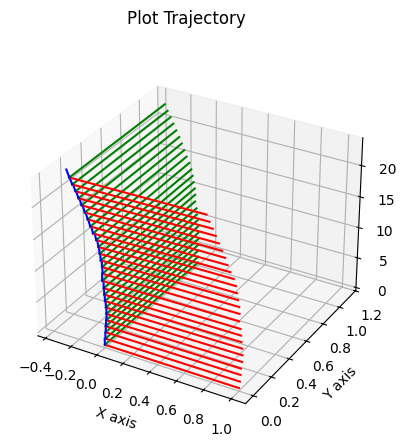

In [11]:
gtsam_plot.plot_trajectory(0, result)

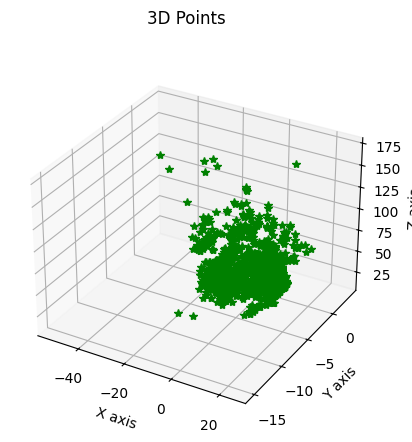

In [12]:
gtsam_plot.plot_3d_points(1, result)

In [14]:
landmark_coords = []
camera_coords = []
for key in result.keys():
    symbol = gtsam.Symbol(key)
    if symbol.chr() == ord('l'):
        landmark_coords.append(result.atPoint3(key))
    if symbol.chr() == ord('x'):
        camera_coords.append(result.atPose3(key).translation())

landmark_coords = np.vstack(landmark_coords)
camera_coords = np.vstack(camera_coords)

In [15]:
print(landmark_coords.shape, camera_coords.shape)

(2634, 3) (26, 3)


In [16]:
result.size()

2660

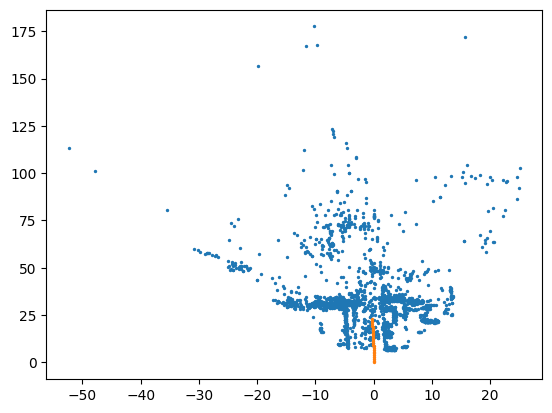

In [17]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.scatter(landmark_coords[:, 0], landmark_coords[:, 2], s=2)
ax1.scatter(camera_coords[:, 0], camera_coords[:, 2], s=2)

In [102]:
import plotly.graph_objects as go

trajectory_trace = go.Scatter3d(
    x=camera_coords[:, 0],
    y=camera_coords[:, 1],
    z=camera_coords[:, 2],
    mode='lines+markers',
    name='Trajectory',
    line=dict(color='blue', width=4),
    marker=dict(size=3)
)

landmark_trace = go.Scatter3d(
    x=landmark_coords[:, 0],
    y=landmark_coords[:, 1],
    z=landmark_coords[:, 2],
    mode='markers',
    name='Landmarks',
    marker=dict(size=2, color='orange')
)

fig = go.Figure(data=[trajectory_trace, landmark_trace])

fig.update_layout(
    title="3D View of SLAM Result",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data',
        camera=dict(
            up=dict(x=0, y=-1, z=0),
            center=dict(x=0, y=0.1, z=0),
            eye=dict(x=-1, y=-1, z=-1)
		)
	),
    margin=dict(l=0, r=0, b=0, t=30)
)

fig.show()